In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 
sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")

import metpy

import meteo


import pandas as pd
from IPython.display import display, HTML


import yk22_mass_fluxes

In [2]:
%load_ext autoreload
%autoreload 2

## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 500)

Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2


Fa_q_eu, Fa_q_or    = (-2e-3)/86400. , (-0.e-3)/86400.   # kg/kg / day
Fa_th_eu , Fa_th_or = -0.75/86400.,       -0./86400.        # K/day
bl_height        = 500.                                    #  mean mixed layer height / m
bl_density       = 1. 


## what height is entrained air from?
entrainment_levels = slice(600, 850)    # m

## what height does convective downdrafts come from?
downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

In [3]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [18]:
## TO USE IN SOLVER find_theta_for_pair
## h_{cd} - s_{cd} - Lv*q_sat(s_{cd}/cp) = 0
## where I find theta as cp*\theta = s_cd
def temp_from_h(theta, p, h_cd, Lv, cp, sat_frac):
    # input:
    # - p : pressure in hPa
    # - h_cd : moist static energy at convective downdraft level, J/kg
    # - Lv : latent heat of vaporization = 2.5e6 J/kg
    # - cp : specific heat dry air = 1004.67 J/kg K
    # - sat_frac : fraction of saturation, to test when different from 1.

    T = theta*(p/1000.)**(Rd/cp) - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    es = 6.1121 * np.exp(17.502 * T / (240.97 + T))
    es = es * (1.0007 + p * 3.46e-6)
    ex = meteo.qsat(T,p)
    es = 0.98 * ex
    qs = 0.622 * es /(p - 0.378 * es)


    # T = theta - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    # es = 6.1121 * np.exp(17.502 * T / (240.97 + T) )     # TRY HERE TO USE theta*(p/1000.)**(R/cp) - returns physically consistent values, but mass fluxes become negative :/
    # denominator = p - 0.378 * es * (1.0007 + p * 3.46e-4)
    
    return h_cd/cp - theta - sat_frac*(Lv / cp)*qs #0.622*es*(1.0007 + p * 3.46e-6) / denominator

from scipy.optimize import root_scalar
def find_theta_for_pair(p, h, sat_frac):
    
    f = lambda t : temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp, sat_frac=sat_frac)

    try:
        sol = root_scalar(f, bracket=[270,350], method='brentq')
        return sol.root if sol.converged else np.nan
    except:
        return np.nan
    
# Vectorize the function
vectorized_theta_root = np.vectorize(find_theta_for_pair)


## this function aims at extracting the thermodynamical properties 
## from entrainment heights and downdrafts, from a single profile at a time
def properties_from_profile(profile, mixed_avg_levels, entrainment_levels, downdraft_levels, CD_sat_frac, vert_dim):

    h_cd = (cp*profile["ta"] + Lv*profile["q"] + g*profile[vert_dim]).sel({vert_dim:downdraft_levels})
    p_cd = profile["p"].sel({vert_dim:downdraft_levels}).values/100.  ## hPa
    sfc_p = 1000*np.ones_like(p_cd)

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    thetaD = (vectorized_theta_root( p_cd , h_cd, sat_frac=CD_sat_frac))   # p_cd, sfc_p
    thetaD = xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    thetaD = thetaD.rename({vert_dim:"height_cd"})

    
    qD = CD_sat_frac*(meteo.qsea((thetaD)-273.15 , sfc_p)/1e3)  # p_cd
    qD = xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    qD = qD.rename({vert_dim:"height_cd"})



    theta_out = profile.theta.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    theta_bl  = profile.theta.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})

    q_out = profile.q.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    q_bl  = profile.q.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})


    return xr.Dataset(
        dict(
            thetaD=thetaD,
            qD=qD,
            theta_out=theta_out,
            theta_bl=theta_bl,
            q_out=q_out,
            q_bl=q_bl
        )
        )


In [19]:
mean_prof_eu = ds_eureca_bco.mean(dim="launch_time")
props_eu = properties_from_profile(mean_prof_eu, mixed_avg_levels, entrainment_levels, downdraft_levels_eu, CD_sat_frac=1., vert_dim="height")


mean_prof_or = ds_orcestra_bco.mean(dim="launch_time")
props_or = properties_from_profile(mean_prof_or, mixed_avg_levels, entrainment_levels, downdraft_levels_or, CD_sat_frac=1., vert_dim="height")


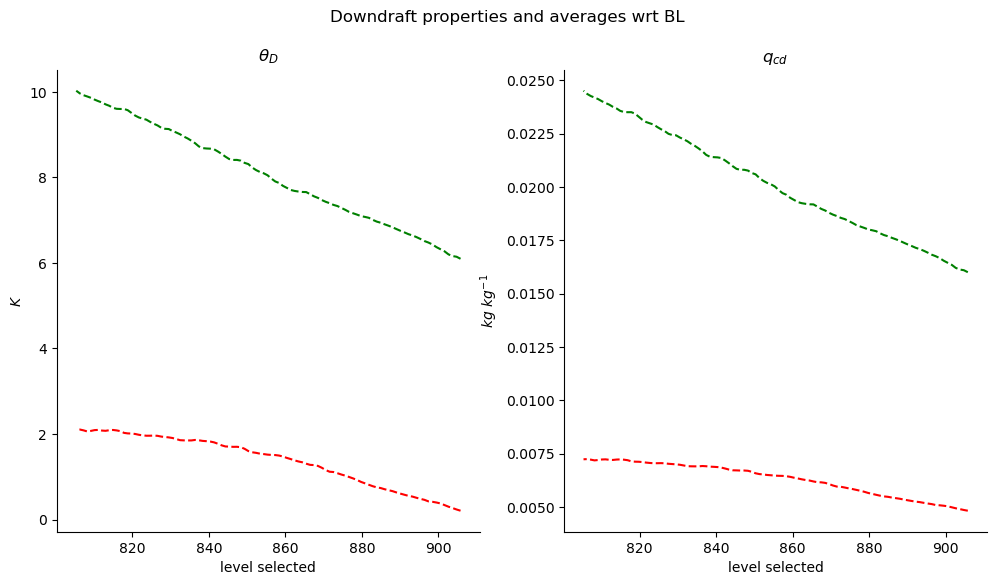

In [20]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Downdraft properties and averages wrt BL")

ax[0].plot(props_eu["thetaD"].p_cd, props_eu["thetaD"] - props_eu["theta_bl"], "--", color="red", label="EUREC4A")
ax[0].plot(props_eu["thetaD"].p_cd, props_or["thetaD"] - props_or["theta_bl"], "--", color="green", label="ORCESTRA")
# ax[0].plot(props_eu["thetaD"].p_cd, props_eu["thetaD"], "--", color="red", label="EUREC4A")
# ax[0].plot(props_eu["thetaD"].p_cd, props_or["thetaD"], "--", color="green", label="ORCESTRA")

# ax[0].hlines(xmin=20, xmax=80, y=props_eu["thetaD"].weighted((props_eu["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_eu["theta_bl"], color="red", label="EUREC4A")
# ax[0].hlines(xmin=20, xmax=80, y=props_or["thetaD"].weighted((props_or["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_or["theta_bl"], color="green", label="ORCESTRA")

ax[0].set_xlabel("level selected")
ax[0].set_ylabel(r"$K$")
ax[0].set_title(r"$\theta_D$")



ax[1].plot(props_eu["qD"].p_cd, props_eu["qD"] - props_eu["q_bl"], "--", color="red", label="EUREC4A")
ax[1].plot(props_eu["qD"].p_cd, props_or["qD"] - props_or["q_bl"], "--", color="green", label="ORCESTRA")
# ax[1].plot(props_eu["qD"].p_cd, props_eu["qD"], "--", color="red", label="EUREC4A")
# ax[1].plot(props_or["qD"].p_cd, props_or["qD"], "--", color="green", label="ORCESTRA")

# ax[1].hlines(xmin=20, xmax=80, y=props_eu["qD"].weighted((props_eu["qD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_eu["q_bl"], color="red", label="EUREC4A")
# ax[1].hlines(xmin=20, xmax=80, y=props_or["qD"].weighted((props_or["qD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_or["q_bl"], color="green", label="ORCESTRA")

ax[1].set_xlabel("level selected")
ax[1].set_ylabel(r"$kg~kg^{-1}$")
ax[1].set_title(r"$q_{cd}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

In [23]:
props_or["qD"]

<xarray.DataArray 'qD' (height_cd: 101)> Size: 808B
array([0.03457233, 0.03466639, 0.03469702, 0.03477454, 0.03491759,
       0.03501231, 0.03510913, 0.03523304, 0.03532329, 0.03539333,
       0.03549029, 0.03557947, 0.03565663, 0.03571624, 0.03579806,
       0.03587251, 0.03595538, 0.03604129, 0.03611584, 0.03618258,
       0.03625841, 0.03631321, 0.0363963 , 0.03649485, 0.03653876,
       0.03657582, 0.03664886, 0.03671355, 0.03677893, 0.03688249,
       0.0369731 , 0.03706474, 0.03712058, 0.03720407, 0.03727234,
       0.03735847, 0.03746502, 0.03754012, 0.0376458 , 0.03775097,
       0.03775626, 0.03777754, 0.03780771, 0.03785592, 0.03795978,
       0.03806034, 0.0382048 , 0.03827965, 0.03842358, 0.03859266,
       0.03869241, 0.03875956, 0.03885688, 0.03898672, 0.03916014,
       0.03922331, 0.03933693, 0.03937525, 0.03937194, 0.03941875,
       0.03954233, 0.03968311, 0.03981103, 0.03992552, 0.03995645,
       0.03996613, 0.03998493, 0.04007341, 0.04024129, 0.04037439,
       0.04049365, 0.04059314, 0.04071384, 0.04080585, 0.04088767,
       0.04099144, 0.04100431, 0.04105886, 0.04118359, 0.04127407,
       0.04137707, 0.04149273, 0.04155217, 0.04161178, 0.04171402,
       0.04185999, 0.04200667, 0.04207547, 0.0420738 , 0.04208294,
       0.04213562, 0.04224944, 0.04232733, 0.04243112, 0.04250444,
       0.04258874, 0.04268718, 0.04276197, 0.04283012, 0.04292955,
       0.04308094])
Coordinates:
  * height_cd  (height_cd) float32 404B 2.5e+03 2.51e+03 ... 3.49e+03 3.5e+03
    p_cd       (height_cd) float32 404B 759.5 758.6 757.7 ... 675.6 674.8 674.0

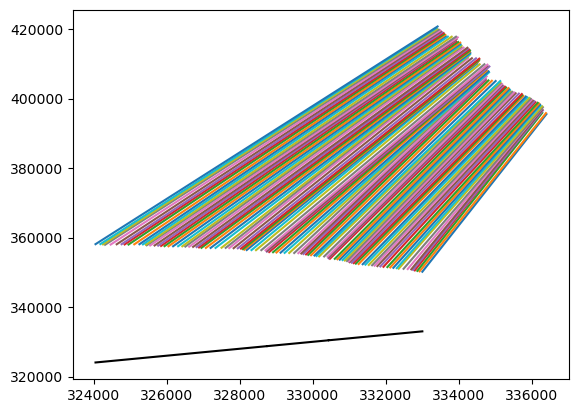

In [21]:
h_eu = (cp*mean_prof_eu["ta"] + Lv*mean_prof_eu["q"] + g*mean_prof_eu["height"]).sel(height=downdraft_levels_eu)
h_or = (cp*mean_prof_or["ta"] + Lv*mean_prof_or["q"] + g*mean_prof_or["height"]).sel(height=downdraft_levels_or)

rec_h_eu = cp*props_eu["thetaD"] + Lv*props_eu["qD"]
rec_h_or = cp*props_or["thetaD"] + Lv*props_or["qD"]


plt.plot([h_eu, h_or], [rec_h_eu, rec_h_or])
plt.plot(h_eu, h_eu, "k")
plt.show()

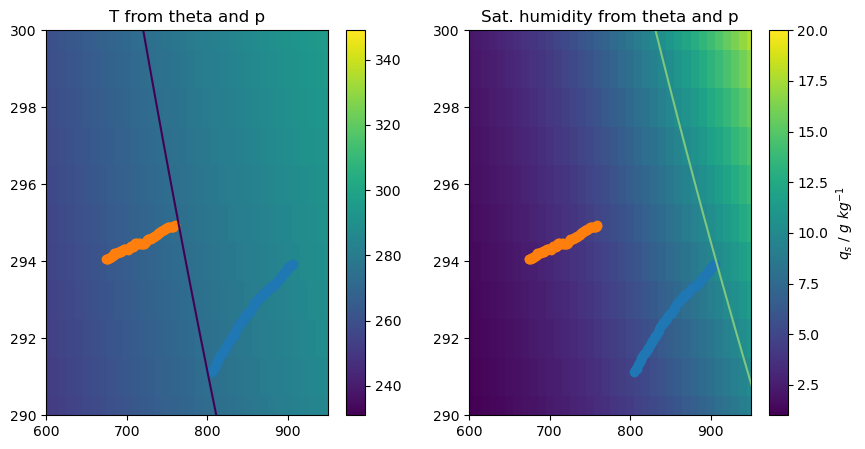

In [10]:
def T(theta, p):
    return theta*(p/1000.)**(Rd/cp)


def qs_from_theta(theta, p):
    T = theta*(p/1000.)**(Rd/cp) - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    es = 6.1121 * np.exp(17.502 * T / (240.97 + T))
    es = es * (1.0007 + p * 3.46e-4)
    ex = meteo.qsat(T,p)
    es = 0.98 * ex
    qs = 622 * es /(p - 0.378 * es)
    return qs



p = np.arange(1000, 500, -10)
theta = np.arange(280, 350)
P, Theta = np.meshgrid(p, theta)


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

c = ax[0].pcolormesh(P, Theta, T(Theta, P))
ax[0].contour(P, Theta, T(Theta, P), levels=[273.15])
ax[0].set_title("T from theta and p")
fig.colorbar(c, ax=ax[0])


c = ax[1].pcolormesh(P, Theta, qs_from_theta(Theta, P), vmin=1., vmax=20.)
ax[1].contour(P, Theta, qs_from_theta(Theta, P), levels=[1, 10, 20], cmap="Greens")
ax[1].set_title("Sat. humidity from theta and p")
fig.colorbar(c, ax=ax[1], label=r"$q_s$ / $g~kg^{-1}$")



for x in ax:
    # x.fill_between([props_eu["p_cd"].min(), props_eu["p_cd"].max()], props_eu["thetaD"].min(), props_eu["thetaD"].max(), alpha=0.3, color='tab:orange', hatch="///")
    # x.fill_between([props_or["p_cd"].min(), props_or["p_cd"].max()], props_or["thetaD"].min(), props_or["thetaD"].max(), alpha=0.3, color='cyan', hatch="///")

    x.scatter(props_eu["p_cd"], props_eu["thetaD"])
    x.scatter(props_or["p_cd"], props_or["thetaD"])

    x.set_xlim(600, 950)
    x.set_ylim(290, 300)

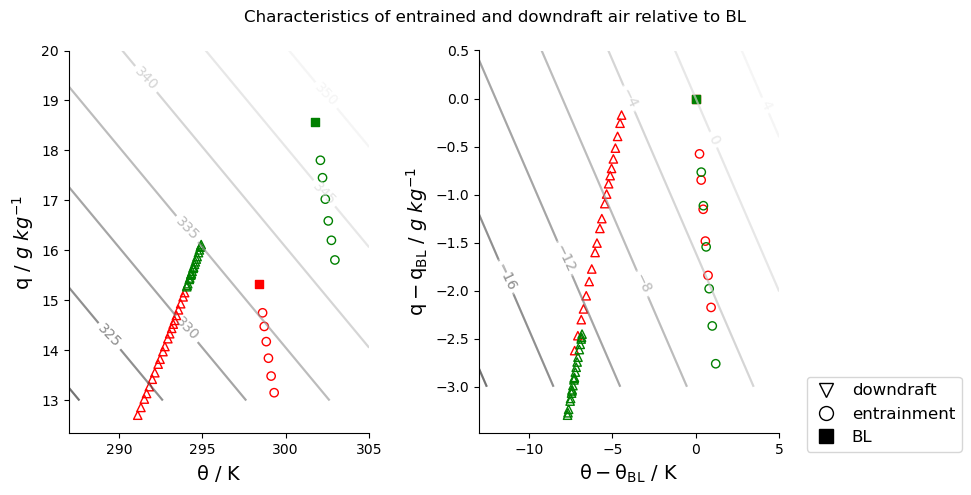

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Characteristics of entrained and downdraft air relative to BL")

th, q = np.linspace(287, 305), np.linspace(0.013*1e3, 0.02*1e3)
dth, dq = np.linspace(-13, 5), np.linspace(-3.e-3*1e3, (5e-4)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



datasets = {
    "eu": dict(color="red", sst=298.,  q_sfc=19.,  theta_bl=props_eu["theta_bl"], q_bl=props_eu["q_bl"],
               theta_out=props_eu["theta_out"][::5], q_out=props_eu["q_out"][::5]*1e3,
               thetaD=props_eu["thetaD"][::5],       qSat=props_eu["qD"][::5]*1e3),
    "or": dict(color="green", sst=301.,  q_sfc=22., theta_bl=props_or["theta_bl"], q_bl=props_or["q_bl"],
               theta_out=props_or["theta_out"][::5], q_out=props_or["q_out"][::5]*1e3,
               thetaD=props_or["thetaD"][::5],       qSat=props_or["qD"][::5]*1e3),
}

for d in datasets.values():
    c, th_bl, q_bl, q_sfc, sst = d["color"], d["theta_bl"], d["q_bl"]*1e3 , d["q_sfc"], d["sst"]

    # absolute coords (ax[0])
    ax[0].scatter(th_bl,        q_bl,        c=c,           marker="s")
    ax[0].scatter(d["theta_out"], d["q_out"], edgecolors=c, marker="o", facecolors="none")
    ax[0].scatter(d["thetaD"],   d["qSat"],  edgecolors=c, marker="^", facecolors="none")
    cs = ax[0].contour(Th, Q, MSE, cmap="Greys_r", alpha=0.4)
    ax[0].clabel(cs, inline=True)
    ax[0].set_xlabel(r"$\rm \theta$ / K", fontsize=14)
    ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$", fontsize=14)


    # relative to BL (ax[1])
    ax[1].scatter(0,                          0,                          c=c,           marker="s")
    ax[1].scatter((d["theta_out"] - th_bl),     (d["q_out"] - q_bl),         edgecolors=c, marker="o", facecolors="none")
    ax[1].scatter((d["thetaD"]    - th_bl),     (d["qSat"]  - q_bl),         edgecolors=c, marker="^", facecolors="none")
    cs = ax[1].contour(DTh, DQ, DMSE, cmap="Greys_r", alpha=0.4)
    ax[1].clabel(cs, inline=True)
    ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K", fontsize=14)
    ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$", fontsize=14)

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

downdraft   = mlines.Line2D([], [], color='black', marker='v', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label=r'downdraft')
 
entrainment = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black',
                            markersize=10, label='entrainment')
 
bl          = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                            markerfacecolor='black', markeredgecolor='black',
                            markersize=10, label='BL')
 
legend = ax[1].legend(handles=[downdraft, entrainment, bl],
                   loc='center', frameon=True, fontsize=12,
                   handlelength=1.5, handletextpad=0.8, bbox_to_anchor=(1.35, 0.05))

plt.tight_layout()

### let's put in the numbers and check energy results

In [15]:
ds_bulkFluxes = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/Bulk_fluxes_from_Meteor.nc")
lhf_recShip_eu = ds_bulkFluxes.LHF_eu.mean(dim="time_eu")
lhf_recShip_or = ds_bulkFluxes.LHF_or.mean(dim="time_or")
shf_recShip_eu = ds_bulkFluxes.SHF_eu.mean(dim="time_eu")
shf_recShip_or = ds_bulkFluxes.SHF_or.mean(dim="time_or")



ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])


In [16]:

RNet_eu = yk22_mass_fluxes.compute_RNet(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_eu.values, 
                props_eu["theta_bl"].values)

E_CD_eu, _, _ = yk22_mass_fluxes.solve_qTh_equations(props_eu, shf_recShip_eu.values, lhf_recShip_eu.values, RNet_eu, Fa_q_eu, Fa_th_eu)



RNet_or = yk22_mass_fluxes.compute_RNet(ingr_or.sw_global.sel(cell=0).mean(dim="time").values,
                ingr_or.lw_diff.sel(cell=0).mean(dim="time").values,
                sst_or.values, 
                props_or["theta_bl"].values)
E_CD_or, _, _ = yk22_mass_fluxes.solve_qTh_equations(props_or, shf_recShip_or.values, lhf_recShip_or.values, RNet_or, Fa_q_or, Fa_th_or)

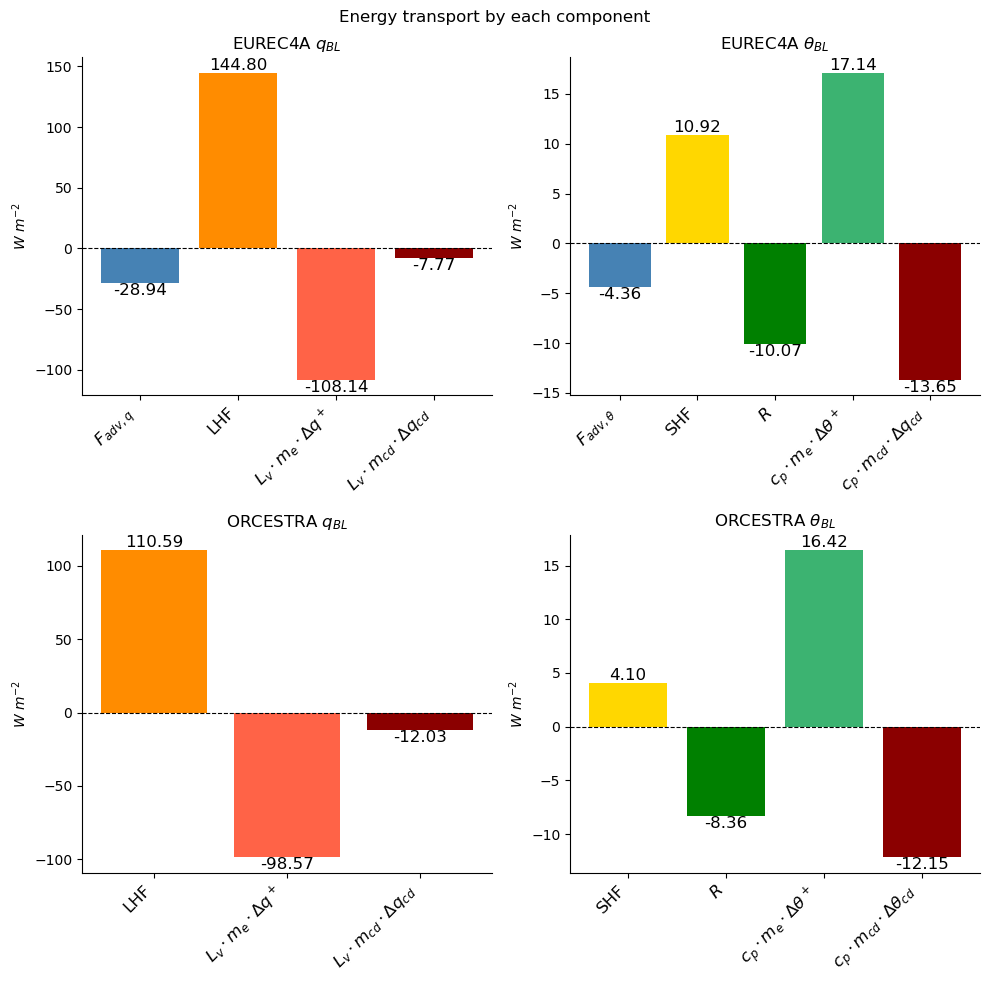

In [17]:
fig, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
fig.suptitle("Energy transport by each component")



labels = [
    r"$F_{adv, q}$",
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "steelblue",        # F_adv
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred"
]


terms_moisture_eu = [(bl_density*bl_height*(Lv*Fa_q_eu)), 
                      lhf_recShip_eu.values, 
                      (E_CD_eu["me"]*Lv*(props_eu["q_out"] - props_eu["q_bl"])).mean().values ,
                      (E_CD_eu["mD"]*Lv*(props_eu["qD"] - props_eu["q_bl"])).mean().values ] 

# bar_values = [terms_moisture_eu[i][0]for i in range(len(terms_moisture_eu))]

all_labels = labels

ax[0].bar(all_labels, terms_moisture_eu, color=colors )   
for i, v in enumerate(terms_moisture_eu):   
    ax[0].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[0].set_title(r"EUREC4A $q_{BL}$")
ax[0].set_ylabel(r"$W~m^{-2}$")
ax[0].set_xticks(range(len(all_labels)))
ax[0].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)







labels = [
    r"$F_{adv, \theta}$",
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e \cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta q_{cd}$"
]


colors = [
    "steelblue",        # F_adv
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred"
]

terms_th_eu = [(bl_density*bl_height*(cp*Fa_th_eu) ),
                shf_recShip_eu.values  ,
                RNet_eu,
                (E_CD_eu["me"]*cp*(props_eu["theta_out"] - props_eu["theta_bl"])).mean().values , 
                (E_CD_eu["mD"]*cp*(props_eu["thetaD"] - props_eu["theta_bl"])).mean().values ] 

# bar_values = [terms_th_eu[i][0]for i in range(len(terms_th_eu))]

all_labels = labels #+ ["res"]

ax[1].bar(all_labels, terms_th_eu , color=colors ) 
for i, v in enumerate(terms_th_eu ): 
    ax[1].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].set_title(r"EUREC4A $\theta_{BL}$")
ax[1].set_ylabel(r"$W~m^{-2}$")
ax[1].set_xticks(range(len(all_labels)))
ax[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



labels = [
    "LHF",
    r"$L_v \cdot m_e\cdot \Delta q^+$",
    r"$L_v \cdot m_{cd}\cdot \Delta q_{cd}$"
]

colors = [
    "darkorange",       # LHF
    "tomato",           # m_e · Δq+
    "darkred",          # m_cd · Δq_cd
]

terms_moisture_or = [lhf_recShip_or.values, 
                     (E_CD_or["me"]*Lv*(props_or["q_out"] - props_or["q_bl"])).mean().values ,
                    ( E_CD_or["mD"]*Lv*(props_or["qD"] - props_or["q_bl"])).mean().values  ] 

# bar_values = [terms_moisture_or[i][0]for i in range(len(terms_moisture_or))]

all_labels = labels #+ ["res"]

ax[2].bar(all_labels, terms_moisture_or , color=colors + ['grey'])    #+ [sum(bar_values)]
for i, v in enumerate(terms_moisture_or ):    #+ [sum(bar_values)]
    ax[2].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[2].set_title(r"ORCESTRA $q_{BL}$")
ax[2].set_ylabel(r"$W~m^{-2}$")
ax[2].set_xticks(range(len(all_labels)))
ax[2].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)








labels = [
    "SHF",
    r"$R$",
    r"$c_p \cdot m_e\cdot \Delta \theta^+$",
    r"$c_p \cdot m_{cd}\cdot \Delta \theta_{cd}$",
]


colors = [
    "gold",             # SHF
    "green",            # R
    "mediumseagreen",   # m_e · Δθ+
    "darkred",        # m_cd · Δθ_cd
]


terms_th_or = [shf_recShip_or.values ,
               RNet_or,
               (E_CD_or["me"]*cp*(props_or["theta_out"] - props_or["theta_bl"])).mean().values ,
               (E_CD_or["mD"]*cp*(props_or["thetaD"]- props_or["theta_bl"])).mean().values  ] 

# bar_values = [terms_th_or[i][0]for i in range(len(terms_th_or))]

all_labels = labels #+ ["res"]

ax[3].bar(all_labels, terms_th_or, color=colors + ['grey'])  # + [sum(bar_values)]
for i, v in enumerate(terms_th_or):  # + [sum(bar_values)]
    ax[3].text(i, v, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=12)
ax[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[3].set_title(r"ORCESTRA $\theta_{BL}$")
ax[3].set_ylabel(r"$W~m^{-2}$")
ax[3].set_xticks(range(len(all_labels)))
ax[3].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=12)



for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


plt.tight_layout()